# Neural signal forecasting v9
## time-aware gated axial attention + temporal conv + GCN

## What's New in v9 Compared to v8
- **Change-aware features (dx, ddx):** v9 augments inputs with first and second differences so the model can detect rapid changes, not just absolute levels.
- **Mid-horizon jump handling:** dx/ddx highlight emerging jumps in the middle horizons, reducing underestimation when trajectories pivot.
- **Stability preserved:** dx/ddx are lightweight feature additions that improve jump sensitivity without adding recurrent instability or amplifying noise.

## What's New in v8 Compared to v7
- **Horizon-aware training:** v8 applies a smooth, sublinear weight to each horizon so long-range errors are emphasized without overpowering near-term accuracy.
- **Calibration-aware analysis:** v8 adds per-horizon interval width and coverage to evaluate uncertainty quality, not just point error.
- **Expected effect:** improved long-horizon sharpness and more interpretable uncertainty bands for real deployment.

In [6]:
# Build dataloader
import torch
import numpy as np
import os
from model_v9 import NFSTNDTModelV9
from utils import *
from trainer import Trainer

input_dir = './'

## What changed in v4
- fix input issue: remove adj from input of forward()

## What's New in v5 Compared to v4
- **New inputs:** optional timestamp tensor `t` with shape `(B, T)` alongside signal `x` (still `(B, T, C, F)`).
- **New modeling assumption:** irregular sampling is allowed; the model uses `delta_t` computed internally from `t`.
- **Architectural change:** time features are encoded (Time2Vec + `delta_t`) and concatenated to signal features *before* the axial attention backbone.
- **Why this helps:** time-awareness reduces the fixed-interval assumption and improves robustness when sampling is uneven or when time context matters.

### Time inputs in this notebook
If your dataset does not include timestamps, we generate a synthetic monotonic `t` using `torch.arange(T)` so the pipeline remains backward compatible. When `delta_t` is constant, v5 behaves like v4 with a richer positional bias.


## Time-aware inputs (v5)
- We construct a timestamp tensor `t` with shape `(B, T)` using `torch.arange(T)` when real timestamps are unavailable.
- The v5 model computes `delta_t = t[:, i] - t[:, i-1]` internally.
- Time2Vec is used inside `model_v5.py` to encode time before the backbone.


In [7]:
# parameters:
dataset_name = 'beignet'
# dataset_name = 'affi'
if dataset_name == 'beignet':
  num_channels = 89
else:
  num_channels = 239

batch_size = 16
num_epochs = 100
learning_rate = 1e-4
hidden_size = 256
n_heads=4
n_layers=3
dropout=0.1
input_size = num_channels

# --- Time-based split (train on past, test on future) ---
# Data is assumed to be ordered in time; we avoid random shuffling here.
raw = np.load(f'dataset/train_data_{dataset_name}.npz')['arr_0']
num_total = len(raw)
train_end = int(num_total * 0.8)
val_end = int(num_total * 0.9)

train_data = raw[:train_end]
val_data = raw[train_end:val_end]
test_data = raw[val_end:]

print(f"Temporal split (indices): train [0:{train_end}), val [{train_end}:{val_end}), test [{val_end}:{num_total})")

Temporal split (indices): train [0:560), val [560:630), test [630:700)


In [8]:
from torch.utils.data import DataLoader
import numpy as np
import torch
import torch.nn as nn

# --- Dataset / Dataloader ---
train_ds = NeuroForcastDataset(train_data, use_graph=False)
np.savez(f'train_data_average_std_{dataset_name}.npz', average=train_ds.average, std=train_ds.std)

test_ds = NeuroForcastDataset(test_data, use_graph=False, average=train_ds.average, std=train_ds.std)
val_ds  = NeuroForcastDataset(val_data,  use_graph=False, average=train_ds.average, std=train_ds.std)

train_data_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_data_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)
val_data_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)

adj_matrix = compute_adj_matrix(train_data, threshold=0.1).to(torch.device('cuda'))

# --- Model ---

# --- Time handling for v5 (synthetic timestamps if none exist) ---
def build_time_tensor(x):
    # x: (B, T, C, F) -> t: (B, T)
    t = torch.arange(x.shape[1], device=x.device, dtype=x.dtype)
    return t.unsqueeze(0).repeat(x.shape[0], 1)

class TimeAwareWrapper(nn.Module):
    """
    Wraps the v5 model so the existing Trainer can call model(x).
    Time is injected here; if you have real timestamps, replace build_time_tensor.
    """
    def __init__(self, base_model):
        super().__init__()
        self.base_model = base_model

    def forward(self, x, t=None):
        if t is None:
            t = build_time_tensor(x)
        return self.base_model(x, t)

class QuantileWrapper(nn.Module):
    """
    v6/v7: converts point output (B, T, C) -> quantile output (B, T, C, Q)
    using a lightweight quantile head.
    """
    def __init__(self, base_model, quantiles):
        super().__init__()
        self.base_model = base_model
        self.quantiles = torch.tensor(quantiles, dtype=torch.float32)
        self.head = nn.Linear(1, len(quantiles))

    def forward(self, x, t=None):
        if t is None:
            t = build_time_tensor(x)
        y = self.base_model(x, t)            # (B, T, C)
        y = y.unsqueeze(-1)                  # (B, T, C, 1)
        return self.head(y)                  # (B, T, C, Q)




class V9QuantileWrapper(nn.Module):
    # Wrap v9 to preserve (B, T, C, Q) outputs for the Trainer.
    # v9 runs on per-channel sequences, so we fold channels into the batch.
    def __init__(self, base_model, quantiles):
        super().__init__()
        self.base_model = base_model
        self.quantiles = quantiles

    def forward(self, x, t=None):
        if t is None:
            t = build_time_tensor(x)
        B, T, C, F = x.shape

        x_flat = x.permute(0, 2, 1, 3).contiguous().view(B * C, T, F)
        t_flat = t.unsqueeze(1).repeat(1, C, 1).view(B * C, T)

        out = self.base_model(x_flat, t_flat)
        y_pred = out["y_pred"]
        if y_pred.dim() == 2:
            y_pred = y_pred.unsqueeze(-1)
        Q = y_pred.shape[-1]

        y_pred = y_pred.view(B, C, T, Q).permute(0, 2, 1, 3).contiguous()
        return y_pred

def horizon_weighted_quantile_loss(y_hat, y_true, quantiles, weights=None):
    """
    Pinball loss for direct multi-horizon forecasting.
    y_hat: (B, H, C, Q)  # already sliced by Trainer for multi_step
    y_true: (B, H, C)
    weights: optional (H,) weighting for horizons
    """
    q = torch.tensor(quantiles, device=y_hat.device, dtype=y_hat.dtype).view(1, 1, 1, -1)
    y_true = y_true.unsqueeze(-1)
    err = y_true - y_hat
    loss = torch.maximum(q * err, (q - 1) * err)  # (B, H, C, Q)

    if weights is None:
        return loss.mean()

    w = torch.tensor(weights, device=y_hat.device, dtype=y_hat.dtype).view(1, -1, 1, 1)
    return (loss * w).sum() / w.sum()


quantiles = [0.1, 0.5, 0.9]
base_model = NFSTNDTModelV9(
    input_size=train_data.shape[-1],
    hidden_size=hidden_size,
    n_heads=n_heads,
    n_layers=n_layers,
    dropout=dropout,
    num_features=train_data.shape[-1],
    quantiles=quantiles
).to(torch.device('cuda'))

model = V9QuantileWrapper(base_model, quantiles).to(torch.device('cuda'))

# --- Loss / Optim / Scheduler ---
# Horizon weighting: set to None for uniform (v6-equivalent)
H = train_data.shape[1] - 10
alpha = 0.7  # set to 0.0 for v7-equivalent uniform weights
h_idx = np.arange(1, H + 1, dtype=np.float32)
horizon_weights = (h_idx / float(H)) ** alpha
loss_fn = lambda y_hat, y_true: horizon_weighted_quantile_loss(y_hat, y_true, quantiles, weights=horizon_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-2)
lambda1 = lambda epoch: 0.95 ** (epoch // 20)   # stable decay
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lambda1)

# --- Trainer ---
save_path = f'./model_{dataset_name}_v9.pth'  # BEST will be saved here
trainer = Trainer(
    model=model,
    train_data_loader=train_data_loader,
    test_data_loader=test_data_loader,
    val_data_loader=val_data_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    device=torch.device('cuda'),
    scheduler=scheduler,
    forecasting_mode='multi_step',
    init_steps=10,
    save_path=save_path,
    ckpt_path=None,
    max_grad_norm=1.0,
    validate_every=1,   # every epoch
    save_best=True
)

trainer.train(num_epochs)
print("Best val:", trainer.best_val)
print("Best weight path:", save_path)

Epoch 1/100: 100%|██████████| 35/35 [00:01<00:00, 23.96it/s, train_loss=505.044962, lr=3.00e-04] 


Epoch 000 | lr=3.000000e-04 | Train=461.755394 | Val=222.370050
[BEST] Saved to ./model_beignet_v9.pth | best_val=222.370050


Epoch 2/100: 100%|██████████| 35/35 [00:00<00:00, 47.12it/s, train_loss=278.970714, lr=3.00e-04]


Epoch 001 | lr=3.000000e-04 | Train=247.088347 | Val=158.149115
[BEST] Saved to ./model_beignet_v9.pth | best_val=158.149115


Epoch 3/100: 100%|██████████| 35/35 [00:00<00:00, 47.28it/s, train_loss=249.437679, lr=3.00e-04]


...

Epoch 097 | lr=2.443519e-04 | Train=120.696641 | Val=127.576247


Epoch 99/100: 100%|██████████| 35/35 [00:00<00:00, 47.93it/s, train_loss=134.872235, lr=2.44e-04]


Epoch 098 | lr=2.443519e-04 | Train=119.458265 | Val=126.166800


Epoch 100/100: 100%|██████████| 35/35 [00:00<00:00, 47.32it/s, train_loss=135.630417, lr=2.44e-04]
                                                               

Epoch 099 | lr=2.321343e-04 | Train=120.129798 | Val=130.017758
Best val: 116.52402877807617
Best weight path: ./model_beignet_v9.pth


## What's New in v6 Compared to v5
- **Why point forecasting is insufficient:** v5 produces a single trajectory, but real neural signals are noisy and multi-modal; a single point hides ambiguity and can be overconfident when the test distribution shifts.
- **What uncertainty means here:** for each future time and channel, multiple plausible outcomes exist due to measurement noise and changing dynamics.
- **How v6 models predictive uncertainty:** v6 predicts multiple **quantiles** of the target distribution (e.g., 0.1, 0.5, 0.9) using a pinball loss. This yields a median forecast plus uncertainty bands.
- **Why this improves robustness under distribution shift:** quantile outputs avoid overconfident point estimates and provide calibrated ranges that remain useful even when patterns differ from training.

## Output shape (v6)
- Model output: `y_hat` has shape `(B, T, C, Q)` where `Q = len(quantiles)`.
- For multi-step forecasting, the trainer compares `y_hat[:, init_steps:, :, :]` against target `(B, H, C)`.

## What's New in v7 Compared to v6
- **Why autoregressive forecasting is problematic:** rolling predictions forward compounds errors and can drift quickly when the data distribution shifts.
- **How direct multi-horizon prediction improves stability:** v7 predicts the entire future window in a single forward pass, avoiding step-by-step error accumulation.
- **Why time-based evaluation is necessary:** random splits leak future patterns into training; strict temporal splits better match real deployment.
- **How v7 better measures generalization:** per-horizon metrics and interval coverage expose where the model degrades as the horizon grows.

## Direct multi-horizon forecasting (v7)
- Forecast horizon `H = T - init_steps` is predicted directly in one pass (no autoregressive rollout).
- Model output for evaluation: `y_hat_future` has shape `(B, H, C, Q)`.
- **Backward compatibility:** when `H = 1` and horizon weights are uniform, v7 reduces to the v6 objective.

## Temporal evaluation protocol (v7)
- **Train:** earliest 80% of samples
- **Val:** next 10%
- **Test:** final 10% (most recent)
- This mirrors real-world deployment where only past data is available for training.

## Horizon-aware loss (v8)
- Each horizon `h` is weighted by `w_h = (h / H) ** alpha`.
- `alpha = 0` recovers v7 (uniform weighting), so v8 is backward compatible.
- All quantiles at the same horizon share the same weight.

Per-horizon MSE (median): [0.004258 0.009446 0.012704 0.013937 0.015262 0.017907 0.018618 0.022392
 0.022556 0.022239]
Per-horizon MAE (median): [0.047933 0.071832 0.083431 0.086975 0.090565 0.099172 0.100271 0.109065
 0.107751 0.1079  ]
Per-horizon 80% interval coverage (q10-q90): [0.868 0.809 0.786 0.811 0.815 0.792 0.788 0.777 0.801 0.802]
Per-horizon interval width (q90-q10): [0.188074 0.245038 0.274287 0.294246 0.307825 0.311415 0.321304 0.338814
 0.344917 0.352379]
Per-horizon upward-jump recall (median deltas): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


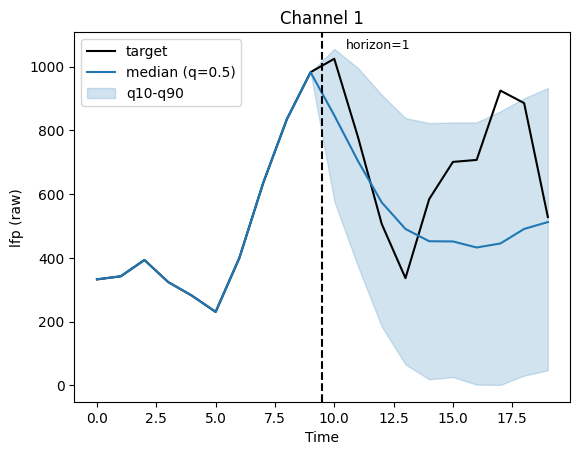

In [9]:
import numpy as np
import torch
import matplotlib.pyplot as plt

INIT_STEPS = 10
DEVICE = torch.device("cuda")

# --- Load BEST model ---
quantiles = [0.1, 0.5, 0.9]
base_model_test = NFSTNDTModelV9(input_size=train_data.shape[-1], hidden_size=hidden_size, n_heads=n_heads, n_layers=n_layers, dropout=dropout, num_features=train_data.shape[-1], quantiles=quantiles).to(DEVICE)
model_test = V9QuantileWrapper(base_model_test, quantiles).to(DEVICE)
model_test.load_state_dict(torch.load(f'./model_{dataset_name}_v9.pth', map_location="cpu"))
model_test.eval()
# --- De-normalization helpers (feature 0 only) ---
stats = np.load(f'train_data_average_std_{dataset_name}.npz')
avg_cf = stats['average']  # (1, C*F)
std_cf = stats['std']
num_feats = avg_cf.shape[1] // num_channels
avg_f0 = avg_cf.reshape(1, num_channels, num_feats)[..., 0]
std_f0 = std_cf.reshape(1, num_channels, num_feats)[..., 0]
combine_max = avg_f0 + 4 * std_f0
combine_min = avg_f0 - 4 * std_f0

def denorm_feature0(x, channel_idx=None):
    x_np = x.detach().cpu().numpy() if torch.is_tensor(x) else x
    if x_np.shape[-1] == num_channels:
        return ((x_np + 1) / 2) * (combine_max - combine_min) + combine_min
    if channel_idx is None:
        raise ValueError("channel_idx required for single-channel inputs")
    cmax = combine_max[..., channel_idx]
    cmin = combine_min[..., channel_idx]
    return ((x_np + 1) / 2) * (cmax - cmin) + cmin

def prepare_input_masked(data, init_steps=INIT_STEPS):
    # data: (B,20,C,F)
    future = data.shape[1] - init_steps
    x_in = torch.cat([
        data[:, :init_steps, :, :],
        data[:, init_steps-1:init_steps, :, :].repeat(1, future, 1, 1)
    ], dim=1)
    y_future = data[:, init_steps:, :, 0]  # (B,10,C) feature0 target
    return x_in, y_future

@torch.no_grad()
def eval_metrics_per_horizon(model, loader, device=DEVICE, init_steps=INIT_STEPS, spike_tau=0.0):
    preds_q, tgts = [], []
    for batch in loader:
        batch = batch.to(device)  # (B,20,C,F)
        x_in, y_future = prepare_input_masked(batch, init_steps=init_steps)
        t_in = build_time_tensor(x_in)

        y_hat_full = model(x_in, t_in)  # (B,20,C,Q)
        y_hat_future = y_hat_full[:, init_steps:, :, :]  # (B,H,C,Q)

        preds_q.append(y_hat_future.detach().cpu())
        tgts.append(y_future.detach().cpu())

    preds_q = torch.cat(preds_q, dim=0)
    tgts = torch.cat(tgts, dim=0)

    q10 = preds_q[..., quantiles.index(0.1)]
    q50 = preds_q[..., quantiles.index(0.5)]
    q90 = preds_q[..., quantiles.index(0.9)]

    mse_h = torch.mean((tgts - q50) ** 2, dim=(0, 2)).numpy()
    mae_h = torch.mean(torch.abs(tgts - q50), dim=(0, 2)).numpy()
    coverage_h = torch.mean(((tgts >= q10) & (tgts <= q90)).float(), dim=(0, 2)).numpy()
    interval_width_h = torch.mean((q90 - q10), dim=(0, 2)).numpy()

    # Optional upward-jump recall using median deltas
    dy_true = tgts[:, 1:, :] - tgts[:, :-1, :]
    dy_true = torch.cat([dy_true[:, :1, :], dy_true], dim=1)
    dy_pred = q50[:, 1:, :] - q50[:, :-1, :]
    dy_pred = torch.cat([dy_pred[:, :1, :], dy_pred], dim=1)
    spike_true = dy_true > spike_tau
    spike_pred = dy_pred > spike_tau
    upward_jump_recall_h = torch.mean((spike_pred & spike_true).float() / (spike_true.float() + 1e-6), dim=(0, 2)).numpy()

    return mse_h, mae_h, coverage_h, interval_width_h, upward_jump_recall_h, preds_q.numpy(), tgts.numpy()

# Optional upward-jump recall threshold (feature0 deltas)
f0 = train_data[..., 0]
dy = f0[:, 1:, :] - f0[:, :-1, :]
abs_dy = np.abs(dy.reshape(-1))
spike_tau = float(np.percentile(abs_dy, 97.5))

mse_h, mae_h, cov_h, width_h, upward_jump_recall_h, pred_future_q, tgt_future = eval_metrics_per_horizon(model_test, test_data_loader, DEVICE, INIT_STEPS, spike_tau=spike_tau)
print("Per-horizon MSE (median):", np.round(mse_h, 6))
print("Per-horizon MAE (median):", np.round(mae_h, 6))
print("Per-horizon 80% interval coverage (q10-q90):", np.round(cov_h, 3))
print("Per-horizon interval width (q90-q10):", np.round(width_h, 6))
print("Per-horizon upward-jump recall (median deltas):", np.round(upward_jump_recall_h, 3))

# --- Plot one example (full 20 steps) with uncertainty band ---

@torch.no_grad()
def plot_channel_quantiles(model, data_loader, channel_idx=1, device=torch.device("cuda"), init_steps=10, denorm=True):
    model.eval()
    batch = next(iter(data_loader)).to(device)   # (B,20,C,F)

    # build masked input
    future = batch.shape[1] - init_steps
    x_in = torch.cat([
        batch[:, :init_steps, :, :],
        batch[:, init_steps-1:init_steps, :, :].repeat(1, future, 1, 1)
    ], dim=1)

    # model output
    t_in = build_time_tensor(x_in)
    y_hat_q = model(x_in, t_in)  # (B,20,C,Q)

    # enforce competition rule: first 10 steps are given
    y_hat_q[:, :init_steps, :, :] = batch[:, :init_steps, :, 0].unsqueeze(-1)

    # pick one sample
    y_true = batch[0, :, channel_idx, 0]
    y_q10 = y_hat_q[0, :, channel_idx, quantiles.index(0.1)]
    y_q50 = y_hat_q[0, :, channel_idx, quantiles.index(0.5)]
    y_q90 = y_hat_q[0, :, channel_idx, quantiles.index(0.9)]

    if denorm:
        y_true = denorm_feature0(y_true, channel_idx=channel_idx)
        y_q10 = denorm_feature0(y_q10, channel_idx=channel_idx)
        y_q50 = denorm_feature0(y_q50, channel_idx=channel_idx)
        y_q90 = denorm_feature0(y_q90, channel_idx=channel_idx)
        ylabel = "lfp (raw)"
    else:
        y_true = y_true.detach().cpu().numpy()
        y_q10 = y_q10.detach().cpu().numpy()
        y_q50 = y_q50.detach().cpu().numpy()
        y_q90 = y_q90.detach().cpu().numpy()
        ylabel = "lfp (normalized)"

    plt.figure()
    plt.plot(y_true, label="target", color="black")
    plt.plot(y_q50, label="median (q=0.5)", color="tab:blue")
    plt.fill_between(np.arange(len(y_q50)), y_q10, y_q90, color="tab:blue", alpha=0.2, label="q10-q90")
    plt.axvline(x=init_steps-0.5, color="black", linestyle="--")
    plt.title(f"Channel {channel_idx}")
    plt.text(init_steps + 0.5, np.max(y_q90), f"horizon=1", fontsize=9)
    plt.xlabel("Time")
    plt.ylabel(ylabel)
    plt.legend()
    plt.show()


plot_channel_quantiles(model_test, test_data_loader, channel_idx=1)

# --- Optional calibration diagnostics ---

def plot_interval_width(width_h):
    plt.figure()
    plt.plot(np.arange(1, len(width_h) + 1), width_h, marker='o')
    plt.title("Interval Width vs Horizon")
    plt.xlabel("Horizon index (h)")
    plt.ylabel("Mean width (q90-q10)")
    plt.show()


def plot_coverage(cov_h):
    plt.figure()
    plt.plot(np.arange(1, len(cov_h) + 1), cov_h, marker='o')
    plt.title("Coverage vs Horizon")
    plt.xlabel("Horizon index (h)")
    plt.ylabel("Empirical coverage")
    plt.ylim(0, 1)
    plt.show()

# Uncomment to visualize calibration across horizons
# plot_interval_width(width_h)
# plot_coverage(cov_h)